In [ ]:
import scanpy as sc
import pandas as pd

# Load the AnnData object
file = "3_Extended_Pan-GI_atlas_all_lineages.h5ad"
adata = sc.read_h5ad(file)

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\_utils\__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [8]:
print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 1596200 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embeddi

,sampleID,level_1_annot,level_2_annot,level_3_annot,n_counts,cell_type_ontology_term_id,sourceID,study,donorID_unified,donor_category,...,tissue_type,donor_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
index,,,,,,,,,,,,,,,,,,,,,
AAACGAATCTCTTGCG-GSM4600896,GSM4600896,Endothelial,Vascular_endothelia,EC_venous,25675.0,CL:0002543,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,vein endothelial cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,^sYrkXY0j-
AAACGCTAGCGACCCT-GSM4600896,GSM4600896,Myeloid,Granulocyte,Mast,4769.0,CL:0000097,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,mast cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,RZn>|*!%R$
AAAGAACAGCGACCCT-GSM4600896,GSM4600896,Endothelial,Vascular_endothelia,EC_capillary,24592.0,CL:0002144,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,capillary endothelial cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,9{Lmd<I}r5
AAAGGGCAGTCACACT-GSM4600896,GSM4600896,Myeloid,Granulocyte,Mast,1532.0,CL:0000097,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,mast cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,Vr<d!plSZw
AAAGGGCCAACACAGG-GSM4600896,GSM4600896,Myeloid,DC,DC_cDC1,25171.0,CL:0000990,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,conventional dendritic cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,<8#9OwPpEd


In [9]:
colon_tissues = [
    'colon', 'ascending colon', 'transverse colon', 'descending colon',
    'sigmoid colon', 'colonic epithelium', 'lamina propria of mucosa of colon',
    'colonic mucosa', 'rectum', 'rectosigmoid junction', 'epithelium of rectum',
    'mucosa of sigmoid colon', 'mucosa of transverse colon',
    'caecum', 'caecum epithelium', 'cecum mucosa', 'vermiform appendix'
]

adata = adata[adata.obs['tissue'].isin(colon_tissues)].copy()
print(adata)

AnnData object with n_obs × n_vars = 471003 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embeddin

In [13]:
# Filter for Large intestine
# QC: Remove cells with counts < 100 for level_2 and level_3

counts_lvl2 = adata.obs['level_2_annot'].value_counts()
print(counts_lvl2)
cells_to_keep_lvl2 = adata.obs['level_2_annot'].isin(counts_lvl2[counts_lvl2 >= 100].index)

level_2_annot
Absorptive               116957
B_plasma                  47539
Secretory                 39616
Conventional_CD4          36135
Fibroblast                34099
Transit_amplifying        26603
Mesoderm                  23707
Immature_B                23159
Mature_B                  22676
Conventional_CD8          19504
Unconventional_T/ILC      16137
Treg                       7877
Smooth_muscle              7780
Vascular_endothelia        7512
Epithelial_stem            5442
Macrophage                 5038
Neuron_progenitor          3827
Granulocyte                3195
Epithelial_progenitor      3088
Pericyte                   3031
Myofibroblast              2787
Monocyte                   2438
DC                         2357
NK                         2078
Glia                       1662
Cycling_epithelia          1604
Neuron                     1341
Enteroendocrine             994
Mesothelium                 762
Cycling_T/NK                740
Lymphatic_endothelia      

In [14]:
counts_lvl3 = adata.obs['level_3_annot'].value_counts()
print(counts_lvl3)
cells_to_keep_lvl3 = adata.obs['level_3_annot'].isin(counts_lvl3[counts_lvl3 >= 100].index)

level_3_annot
Colonocyte             73617
Goblet                 36982
B_plasma_IgA1          34773
Mature_colonocyte      31636
TA                     26603
                       ...  
Eosinophil/basophil       15
ICC                       12
Follicular_DC              9
SMC_CAPN3_cycling          4
Macrophage_CD5L            1
Name: count, Length: 101, dtype: int64


In [19]:
# Combine the QC filters
cells_to_keep = cells_to_keep_lvl2 & cells_to_keep_lvl3
adata = adata[cells_to_keep].copy()

print(adata)

AnnData object with n_obs × n_vars = 470458 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embeddin

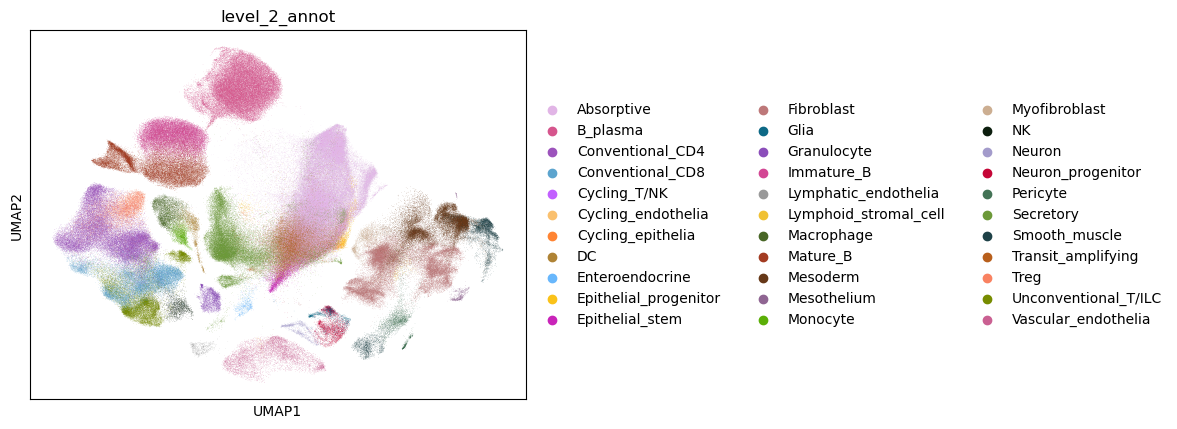

In [20]:
sc.pl.umap(adata, color="level_2_annot")

In [23]:
adata_stem = adata[adata.obs['level_2_annot'] == "Epithelial_stem"].copy()
print(adata_stem)

AnnData object with n_obs × n_vars = 5442 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embedding'

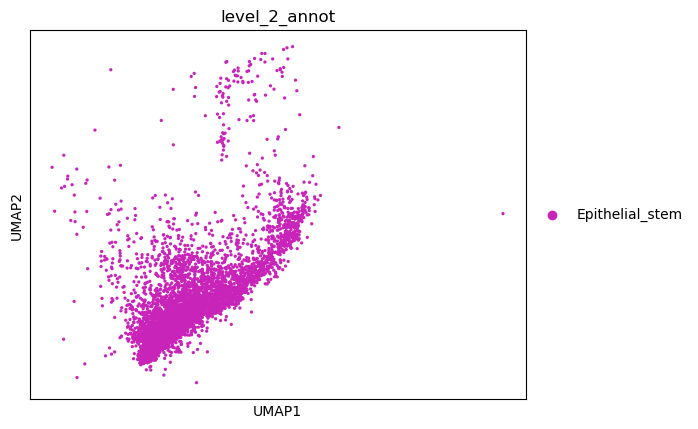

In [26]:
sc.pl.umap(adata_stem, color=["level_2_annot"])

In [31]:
# Count by tissue
print(adata_stem.obs['tissue'].value_counts())

# Count by donor
print(adata_stem.obs['donorID_unified'].value_counts())


tissue
colon                                1526
colonic epithelium                   1203
ascending colon                       520
sigmoid colon                         379
vermiform appendix                    307
lamina propria of mucosa of colon     280
epithelium of rectum                  274
descending colon                      269
caecum                                167
mucosa of transverse colon            149
transverse colon                      135
colonic mucosa                         56
mucosa of sigmoid colon                50
rectosigmoid junction                  47
rectum                                 40
caecum epithelium                      25
cecum mucosa                           15
Name: count, dtype: int64
donorID_unified
F16     310
D12     300
F18     285
D11     265
D212    250
       ... 
D173      2
D52       2
D137      2
D50       1
D51       1
Name: count, Length: 80, dtype: int64


In [40]:
study_median_per_donor = ct.apply(lambda row: row[row > 0].median(), axis=1)

keep_studies = study_total[
    (study_total >= 500) |
    (study_median_per_donor >= 50)
].index

ct_filtered = ct.loc[keep_studies]
ct_filtered = ct_filtered.loc[:, (ct_filtered != 0).any(axis=0)]

ct_filtered.loc['All'] = ct_filtered.sum()
ct_filtered['All'] = ct_filtered.sum(axis=1)

# Get filtered donors and studies
filtered_donors = [c for c in ct_filtered.columns if c != 'All']
filtered_studies = [i for i in ct_filtered.index if i != 'All']

# Build donor metadata
donor_meta = adata_stem.obs[
    adata_stem.obs['donorID_unified'].isin(filtered_donors) &
    adata_stem.obs['study'].isin(filtered_studies)
][['donorID_unified', 'study', 'donor_disease', 'control_vs_disease',
   'sex', 'age_unified', 'tissue', 'donor_category']].drop_duplicates().sort_values(['study', 'donorID_unified'])

# Write both tables to the same sheet with a gap in between
with pd.ExcelWriter("stem_cells_by_study.xlsx", engine='openpyxl') as writer:
    ct_filtered.to_excel(writer, sheet_name="Cell_counts", index=True)
    donor_meta.to_excel(writer, sheet_name="Donor_metadata", index=False)

print("Saved with 2 sheets: Cell_counts + Donor_metadata")

print("Saved to stem_cells_by_study.xlsx")
print(ct_filtered)
print(donor_meta)

Saved with 2 sheets: Cell_counts + Donor_metadata
Saved to stem_cells_by_study.xlsx
donorID_unified  D9  D11  D12  D13  D14  D15  D31  D32  D33  D35  ...  D236  \
study                                                             ...         
Elmentaite2021   81  265  300  124   50   18    0    0    0    0  ...     0   
Kong2023          0    0    0    0    0    0    0    0    0    0  ...    37   
Parikh2019        0    0    0    0    0    0   26   83  104    0  ...     0   
Wang2020          0    0    0    0    0    0    0    0    0  152  ...     0   
Yu2021            0    0    0    0    0    0    0    0    0    0  ...     0   
All              81  265  300  124   50   18   26   83  104  152  ...    37   

donorID_unified  D237  F10  F11  F12  F15  F16  F18  F25   All  
study                                                           
Elmentaite2021      0  102   54   77   32  310    0    0  1413  
Kong2023           18    0    0    0    0    0    0    0  1783  
Parikh2019          0  

In [41]:
# Pull Kong2023 (CD) and Parikh2019 (UC) stem cells only
# Exclude in utero, keep adult disease + control only
studies_keep = ['Kong2023', 'Parikh2019']

adata_dr = adata_stem[
    adata_stem.obs['study'].isin(studies_keep) &
    (adata_stem.obs['donor_category'] != 'inutero') &
    (adata_stem.obs['donor_category'].isin(['control', 'disease']))
].copy()

# Drop low-cell donors (D180: 3 cells — unreliable for co-expression)
adata_dr = adata_dr[adata_dr.obs['donorID_unified'] != 'D180'].copy()

print(adata_dr)
print()
print(adata_dr.obs.groupby(['study', 'donor_category']).size())

AnnData object with n_obs × n_vars = 2488 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embedding'

C:\Users\selim\AppData\Local\Temp\ipykernel_41692\3719999543.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata_dr.obs.groupby(['study', 'donor_category']).size())


In [43]:
import numpy as np
from scipy.sparse import issparse
from qubo_dr.pipeline import run_pipeline

# ── Kong2023 (Crohn's disease) ─────────────────────────────────────
adata_cd = adata_dr[adata_dr.obs['study'] == 'Kong2023'].copy()

X_cd = adata_cd.X.toarray().T if issparse(adata_cd.X) else adata_cd.X.T
g_cd = list(adata_cd.var_names)
batch_cd = adata_cd.obs['donor_category'].values   # 'disease' or 'control'

results_cd = run_pipeline(
    X            = X_cd,
    g            = g_cd,
    batch_id     = batch_cd,
    cond_a_label = 'disease',
    cond_b_label = 'control',
    source       = 'kegg',
    pathway_id   = 'hsa04310',   # Wnt/β-catenin
    K            = 15,
    num_reads    = 1000,
    plotit       = True,
    outfile      = 'qubo_genes_CD_wnt.txt',
)

print("── CD selected genes ──")
print(results_cd['sub_g_net'])

Fetching KEGG pathway: hsa04310


ValueError: Failed to fetch KEGG pathway path:humanhsa04310: 404 Client Error: Not Found for url: https://rest.kegg.jp/get/path:humanhsa04310

In [ ]:
# ── Parikh2019 (Ulcerative colitis) ───────────────────────────────
adata_uc = adata_dr[adata_dr.obs['study'] == 'Parikh2019'].copy()

X_uc = adata_uc.X.toarray().T if issparse(adata_uc.X) else adata_uc.X.T
g_uc = list(adata_uc.var_names)
batch_uc = adata_uc.obs['donor_category'].values

results_uc = run_pipeline(
    X            = X_uc,
    g            = g_uc,
    batch_id     = batch_uc,
    cond_a_label = 'disease',
    cond_b_label = 'control',
    source       = 'kegg',
    pathway_id   = 'hsa04310',
    K            = 15,
    num_reads    = 1000,
    plotit       = True,
    outfile      = 'qubo_genes_UC_wnt.txt',
)

print("── UC selected genes ──")
print(results_uc['sub_g_net'])

In [ ]:

# ── Quick overlap between the two runs ────────────────────────────
cd_genes = set(results_cd['sub_g_net'])
uc_genes = set(results_uc['sub_g_net'])
print(f"\nShared across CD and UC: {cd_genes & uc_genes}")